In [5]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import os

In [3]:
df = pd.read_parquet('/home/vineeth/Documents/GitWorkSpace/FAISS_compression/data')
df.head()

,id,embed0,embed1,embed2,embed3,embed4,embed5,embed6,embed7,embed8,...,embed80,embed81,embed82,embed83,embed84,embed85,embed86,embed87,embed88,embed89
0,user_0,0.070599,0.179204,0.137977,0.112844,0.029409,0.029404,0.010948,0.163269,0.113307,...,0.162690,0.117488,0.062372,0.011980,0.058618,0.061295,0.137527,0.120176,0.167235,0.089010
1,user_1,0.022826,0.136129,0.145202,0.107124,0.147145,0.094245,0.099768,0.081600,0.004851,...,0.129319,0.003166,0.097737,0.043229,0.123137,0.033279,0.131871,0.073812,0.178783,0.026247
2,user_2,0.058654,0.019514,0.159023,0.150879,0.044359,0.113500,0.140540,0.095480,0.091086,...,0.105765,0.170263,0.024091,0.089139,0.150885,0.127392,0.119868,0.120809,0.061823,0.050490
3,user_3,0.153889,0.154032,0.164862,0.173640,0.097225,0.095356,0.151785,0.123582,0.133469,...,0.095664,0.162850,0.125241,0.030980,0.013418,0.122147,0.005041,0.111377,0.178772,0.109418
4,user_4,0.067719,0.112226,0.079946,0.095187,0.164245,0.067358,0.167687,0.157945,0.034157,...,0.014801,0.172127,0.065294,0.064661,0.141799,0.165254,0.172015,0.131432,0.065641,0.014567


<h1>Inspect the Codebook</h1>

In [6]:
# Load the codebook
codebook_path = "/home/vineeth/Documents/GitWorkSpace/FAISS_compression/results/clustering/codebook.npy"
codebook = np.load(codebook_path)

print(f"Codebook shape: {codebook.shape}")
print(f"Number of centroids: {codebook.shape[0]}")
print(f"Dimensions per centroid: {codebook.shape[1]}")

Codebook shape: (500, 90)
Number of centroids: 500
Dimensions per centroid: 90


<h1>Inspect Assignments</h1>

In [9]:
# Load the assignments and codebook
assignments_path = "/home/vineeth/Documents/GitWorkSpace/FAISS_compression/results/clustering/assignments.npy"
codebook_path = "/home/vineeth/Documents/GitWorkSpace/FAISS_compression/results/clustering/codebook.npy"

assignments = np.load(assignments_path)
codebook = np.load(codebook_path)

print(f"Assignments shape: {assignments.shape}")
print(f"Number of vectors: {len(assignments)}")
print(f"Number of unique clusters: {len(np.unique(assignments))}")

Assignments shape: (1000000,)
Number of vectors: 1000000
Number of unique clusters: 500


In [ ]:
# Distribution of clusters
cluster_counts = np.bincount(assignments)
sorted_clusters = np.argsort(-cluster_counts)  # Sort in descending order

# Basic statistics
print("\nCluster assignment statistics:")
print(f"Min cluster size: {np.min(cluster_counts[cluster_counts > 0])}")
print(f"Max cluster size: {np.max(cluster_counts)}")
print(f"Mean cluster size: {np.mean(cluster_counts[cluster_counts > 0]):.2f}")
print(f"Median cluster size: {np.median(cluster_counts[cluster_counts > 0]):.2f}")
print(f"Empty clusters: {np.sum(cluster_counts == 0)}")


Cluster assignment statistics:
Min cluster size: 1
Max cluster size: 2242
Mean cluster size: 2000.00
Median cluster size: 2017.00
Empty clusters: 0


<h1>Visualize </h1>

Codebook shape: (10, 3)
Assignments shape: (1000,)
Found 1 parquet files
Auto-detected 3 embedding columns
Total vectors available: 1000


Loading samples: 100%|██████████| 1/1 [00:00<00:00, 479.51it/s]


Loaded 1000 sample vectors
Main sample size: 995
Query sample size: 5


Finding assignments for main vectors: 100%|██████████| 995/995 [00:00<00:00, 134767.09it/s]

Assignments for query vectors:
Query 1 (ID: user_619): Cluster 4
Query 2 (ID: user_423): Cluster 9
Query 3 (ID: user_880): Cluster 6
Query 4 (ID: user_391): Cluster 4
Query 5 (ID: user_441): Cluster 5
Computing t-SNE projection (this may take a while)...



/tmp/ipykernel_3145/862986600.py:164: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('viridis', n_clusters)


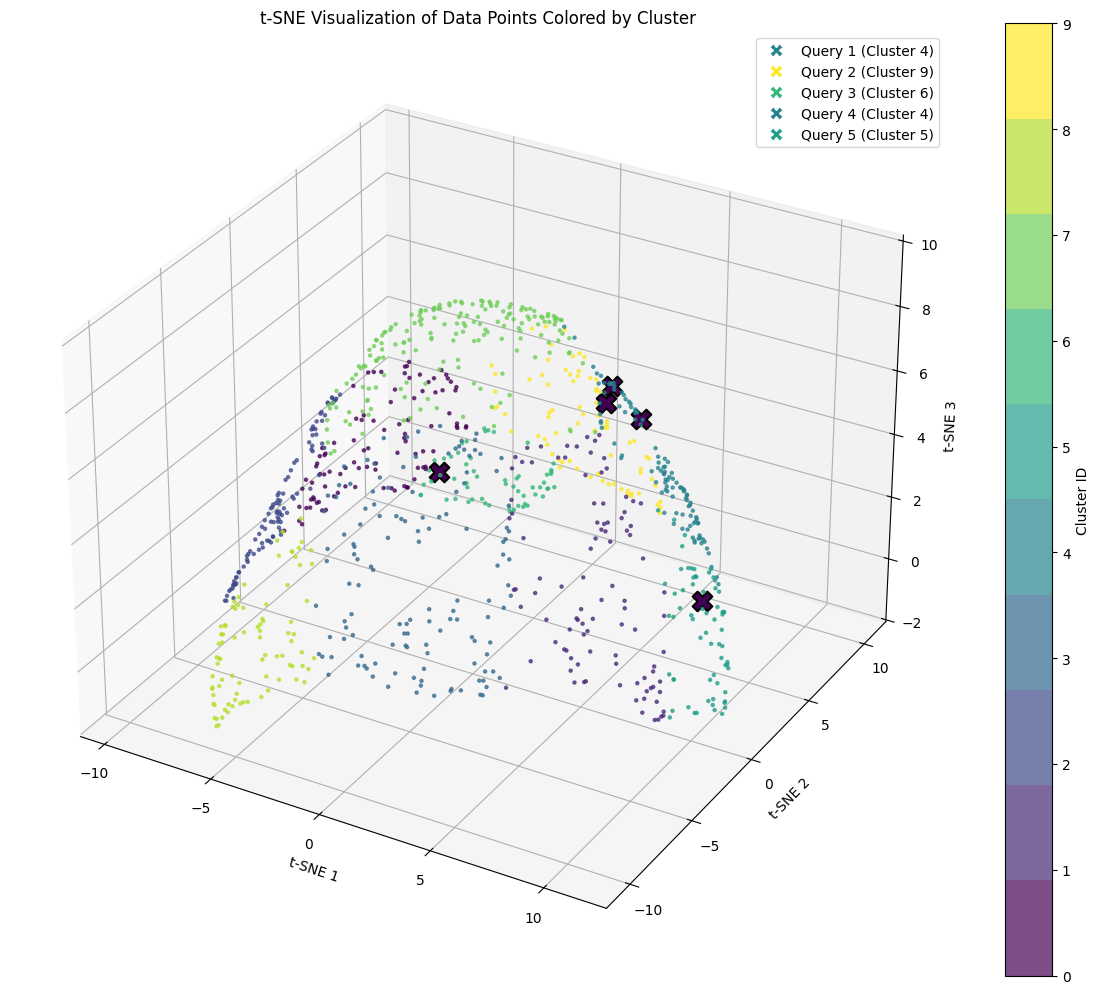

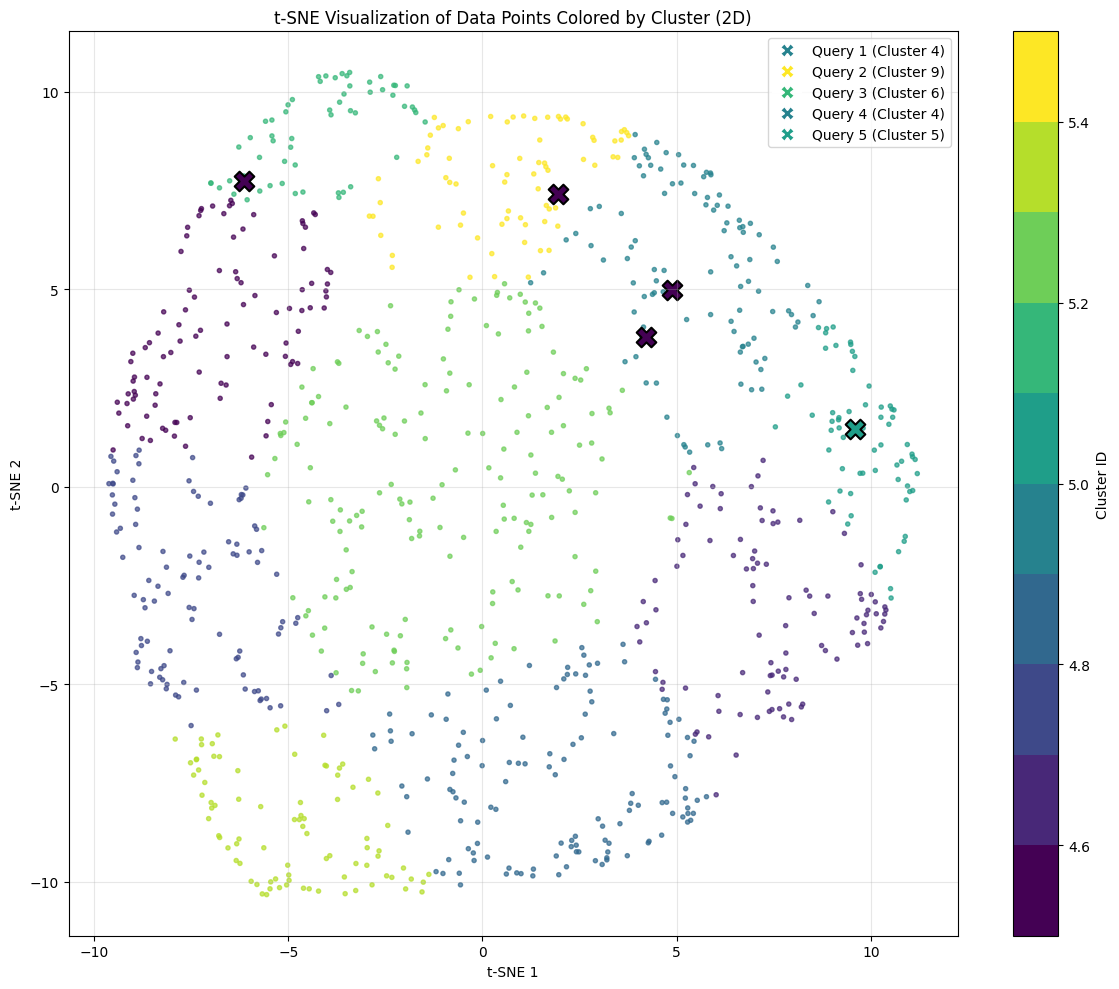

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
import glob
import os
from sklearn.manifold import TSNE
import random
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns

# Paths
data_dir = "../data/synthetic"  # Directory containing parquet files
codebook_path = "../results/clustering/codebook.npy"  # Path to codebook
assignments_path = "../results/clustering/assignments.npy"  # Path to assignments

# Load codebook and assignments
codebook = np.load(codebook_path)
assignments = np.load(assignments_path)

print(f"Codebook shape: {codebook.shape}")
print(f"Assignments shape: {assignments.shape}")

# Function to load data using the same approach as in the parquet loader
def load_sample_from_parquet(directory_path, sample_size=1000, exclude_files=None):
    """
    Load a random sample of vectors from parquet files
    """
    if exclude_files is None:
        exclude_files = ['metadata.parquet']
    
    # Find all parquet files
    parquet_files = [f for f in os.listdir(directory_path) 
                     if f.endswith('.parquet') and f not in exclude_files]
    
    if not parquet_files:
        raise FileNotFoundError(f"No parquet files found in {directory_path}")
    
    print(f"Found {len(parquet_files)} parquet files")
    
    # Load the first file to determine structure
    first_file = os.path.join(directory_path, parquet_files[0])
    sample_df = pd.read_parquet(first_file)
    
    # Auto-detect embedding columns
    embedding_columns = [col for col in sample_df.columns if col.startswith('embed')]
    if not embedding_columns:
        embedding_columns = [col for col in sample_df.columns if col != 'id']
    
    n_dimensions = len(embedding_columns)
    print(f"Auto-detected {n_dimensions} embedding columns")
    
    # Count total vectors across all files
    total_vectors = 0
    for file in parquet_files:
        file_path = os.path.join(directory_path, file)
        df_sample = pd.read_parquet(file_path, columns=['id'] if 'id' in pd.read_parquet(file_path, columns=[]).columns else None)
        total_vectors += len(df_sample)
    
    print(f"Total vectors available: {total_vectors}")
    
    # Determine how many vectors to sample from each file
    sample_per_file = max(1, sample_size // len(parquet_files))
    
    # Initialize result arrays
    vectors = np.zeros((sample_size, n_dimensions), dtype='float32')
    ids = []
    
    # Load random samples from each file
    loaded_count = 0
    
    for file in tqdm(parquet_files, desc="Loading samples"):
        if loaded_count >= sample_size:
            break
            
        file_path = os.path.join(directory_path, file)
        df = pd.read_parquet(file_path)
        
        # Determine how many samples to take from this file
        n_to_sample = min(sample_per_file, len(df), sample_size - loaded_count)
        
        if n_to_sample <= 0:
            continue
            
        # Random sample
        sampled_indices = random.sample(range(len(df)), n_to_sample)
        sampled_df = df.iloc[sampled_indices]
        
        # Extract vectors and IDs
        batch_vectors = sampled_df[embedding_columns].values.astype('float32')
        vectors[loaded_count:loaded_count + n_to_sample] = batch_vectors
        
        if 'id' in df.columns:
            batch_ids = sampled_df['id'].tolist()
            ids.extend(batch_ids)
        else:
            ids.extend([f"unknown_{i}" for i in range(loaded_count, loaded_count + n_to_sample)])
        
        loaded_count += n_to_sample
    
    # If we couldn't load enough samples, trim the arrays
    if loaded_count < sample_size:
        vectors = vectors[:loaded_count]
        ids = ids[:loaded_count]
    
    print(f"Loaded {loaded_count} sample vectors")
    return vectors, ids

# Load a sample from the original data
sample_size = 1000  # Total sample size
query_size = 5      # Number of points to reserve for queries
random.seed(42)     # For reproducibility

# Load sample vectors
sample_vectors, sample_ids = load_sample_from_parquet(data_dir, sample_size=sample_size)

# Split into main sample and query vectors
query_indices = random.sample(range(sample_size), query_size)
main_indices = [i for i in range(sample_size) if i not in query_indices]

query_vectors = sample_vectors[query_indices]
main_vectors = sample_vectors[main_indices]
query_ids = [sample_ids[i] for i in query_indices]
main_ids = [sample_ids[i] for i in main_indices]

print(f"Main sample size: {len(main_vectors)}")
print(f"Query sample size: {len(query_vectors)}")

# Find cluster assignments for our samples
# First for main vectors
main_assignments = np.zeros(len(main_vectors), dtype=int)
for i, vector in enumerate(tqdm(main_vectors, desc="Finding assignments for main vectors")):
    distances = np.linalg.norm(vector - codebook, axis=1)
    main_assignments[i] = np.argmin(distances)

# Then for query vectors
query_assignments = np.zeros(len(query_vectors), dtype=int)
for i, vector in enumerate(query_vectors):
    distances = np.linalg.norm(vector - codebook, axis=1)
    query_assignments[i] = np.argmin(distances)

print("Assignments for query vectors:")
for i, (q_id, cluster) in enumerate(zip(query_ids, query_assignments)):
    print(f"Query {i+1} (ID: {q_id}): Cluster {cluster}")

# Create dataset for t-SNE (main points and query points only, no centroids)
combined_vectors = np.vstack([main_vectors, query_vectors])

# Use t-SNE to project to 3D
print("Computing t-SNE projection (this may take a while)...")
tsne = TSNE(n_components=3, random_state=42, perplexity=min(30, len(combined_vectors) - 1))
combined_tsne = tsne.fit_transform(combined_vectors)

# Split the results back into our groups
main_tsne = combined_tsne[:len(main_vectors)]
query_tsne = combined_tsne[len(main_vectors):]

# Create a 3D plot
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

# Create a colormap with enough colors for all clusters
n_clusters = max(max(main_assignments), max(query_assignments)) + 1
cmap = plt.cm.get_cmap('viridis', n_clusters)

# Plot main vectors colored by cluster assignment
scatter_main = ax.scatter(main_tsne[:, 0], main_tsne[:, 1], main_tsne[:, 2], 
                         c=main_assignments, cmap=cmap, marker='.', alpha=0.7, label='Data Points')

# Plot query vectors with different marker and size but same color scheme
for i, (q_tsne, cluster_id) in enumerate(zip(query_tsne, query_assignments)):
    ax.scatter(q_tsne[0], q_tsne[1], q_tsne[2], 
               c=[[cluster_id]], cmap=cmap, marker='X', s=200, edgecolor='black', linewidth=1.5,
               label=f'Query Point {i+1}')

# Add a color bar
cbar = plt.colorbar(scatter_main, ax=ax, label='Cluster ID')

# Add legend for the query points only
# Create a custom legend for query points
query_legend_handles = []
for i in range(query_size):
    query_legend_handles.append(plt.Line2D([0], [0], marker='X', color='w', 
                               markerfacecolor=cmap(query_assignments[i]/n_clusters), 
                               markersize=10, label=f'Query {i+1} (Cluster {query_assignments[i]})'))

ax.legend(handles=query_legend_handles, loc='best')

ax.set_title('t-SNE Visualization of Data Points Colored by Cluster')
ax.set_xlabel('t-SNE 1')
ax.set_ylabel('t-SNE 2')
ax.set_zlabel('t-SNE 3')

plt.tight_layout()
plt.show()

# Create a 2D version as well (sometimes easier to interpret)
plt.figure(figsize=(12, 10))
plt.scatter(main_tsne[:, 0], main_tsne[:, 1], c=main_assignments, cmap=cmap, marker='.', alpha=0.7)

# Plot query vectors
for i, (q_tsne, cluster_id) in enumerate(zip(query_tsne, query_assignments)):
    plt.scatter(q_tsne[0], q_tsne[1], c=[[cluster_id]], cmap=cmap, marker='X', s=200, 
                edgecolor='black', linewidth=1.5, label=f'Query {i+1}')

plt.colorbar(label='Cluster ID')
plt.title('t-SNE Visualization of Data Points Colored by Cluster (2D)')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')

# Add legend for query points only
plt.legend(handles=query_legend_handles, loc='best')

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()